# Day 1 — ช่วงเช้า: Notebook สาธิตทฤษฎี

โน้ตบุ๊กนี้ทำให้ตัวอย่างจากสไลด์ช่วงเช้า **รันได้จริงและเห็นตัวเลข** ไม่ใช่แค่ดูบนสไลด์
เป็นแบบ step-by-step โค้ดครบทุกเซลล์ รันตามลำดับจากบนลงล่างได้เลย

**เนื้อหา**
1. Perceptron คำนวณด้วยมือ
2. ทำไมต้องมี activation (พิสูจน์ด้วยตัวเลข + ภาพ)
3. Activation function หน้าตาเป็นอย่างไร
4. Softmax แปลงคะแนนเป็นความน่าจะเป็น
5. Crossentropy ลงโทษความมั่นใจที่ผิด
6. Gradient descent เดินลงเขา
7. Epoch / Batch / Step

> โน้ตบุ๊กนี้ใช้แค่ numpy กับ matplotlib ไม่ต้องมี GPU และรันได้เร็ว


## ขั้นเตรียม — โหลดไลบรารี

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
print("พร้อมแล้ว")

พร้อมแล้ว


> **ถ้าตัวอักษรไทยในกราฟกลายเป็นสี่เหลี่ยม** (มักเกิดบน Colab) ให้รันเซลล์ด้านล่างหนึ่งครั้ง
> เพื่อดาวน์โหลดฟอนต์ไทยให้ matplotlib แล้วรันกราฟใหม่ — ถ้าตัวอักษรไทยแสดงปกติอยู่แล้ว ข้ามเซลล์นี้ได้

In [2]:
import urllib.request, pathlib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# ดาวน์โหลดฟอนต์ไทยด้วย Python ล้วน (ไม่ต้องมี wget) และมี timeout กันค้าง
url = "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf"
font_path = pathlib.Path.home() / ".fonts" / "Sarabun-Regular.ttf"
font_path.parent.mkdir(parents=True, exist_ok=True)

try:
    if not font_path.exists():
        urllib.request.urlretrieve(url, font_path)
    fm.fontManager.addfont(str(font_path))
    plt.rcParams['font.family'] = 'Sarabun'
    print("ตั้งฟอนต์ไทยเรียบร้อย")
except Exception as e:
    print("ข้ามการตั้งฟอนต์ (กราฟจะแสดงภาษาไทยไม่ได้):", e)


ตั้งฟอนต์ไทยเรียบร้อย


---
## 1. Perceptron คำนวณด้วยมือ

จากสไลด์: หนึ่งหน่วยรับค่านำเข้าหลายค่า คูณด้วย weight รวมกัน บวก bias แล้วผ่าน activation

$$z = (x_1 w_1) + (x_2 w_2) + b$$


### ขั้นที่ 1.1 — นิยาม ReLU และคำนวณตามค่าในสไลด์

In [3]:
def relu(z):
    return max(0, z)

# ค่าจากสไลด์
x1, x2 = 2, 3
w1, w2 = 0.5, -1.0
b = 1.0

z = (x1 * w1) + (x2 * w2) + b
print(f"z = ({x1}x{w1}) + ({x2}x{w2}) + {b} = {z}")
print(f"ReLU(z) = max(0, {z}) = {relu(z)}")
print("-> หน่วยนี้ไม่ส่งสัญญาณออกไป" if relu(z) == 0 else "-> หน่วยส่งสัญญาณออกไป")

z = (2x0.5) + (3x-1.0) + 1.0 = -1.0
ReLU(z) = max(0, -1.0) = 0
-> หน่วยนี้ไม่ส่งสัญญาณออกไป


### ขั้นที่ 1.2 — เปลี่ยนค่า weight แล้วดูผล

ตามสไลด์: ปรับ `w2` จาก -1.0 เป็น -0.2 ผลลัพธ์เปลี่ยนทันที


In [4]:
w2_new = -0.2
z_new = (x1 * w1) + (x2 * w2_new) + b
print(f"w2 = {w2_new}  ->  z = {z_new}")
print(f"ReLU(z) = {relu(z_new)}   (ตอนนี้หน่วยส่งสัญญาณแล้ว)")

w2 = -0.2  ->  z = 1.4
ReLU(z) = 1.4   (ตอนนี้หน่วยส่งสัญญาณแล้ว)


---
## 2. ทำไมต้องมี activation

จากสไลด์: การแปลงเชิงเส้นซ้อนกันหลายชั้น ยังเทียบเท่าการแปลงเชิงเส้นชั้นเดียว


### ขั้นที่ 2.1 — พิสูจน์ด้วยตัวเลข

เอาสองชั้นเชิงเส้น (ไม่มี activation) มาต่อกัน แล้วดูว่ายุบเป็นชั้นเดียวได้


In [5]:
# ชั้น 1: y1 = 2x + 1
# ชั้น 2: y2 = 3*y1 - 4
x = np.array([0, 1, 2, 3, 4])

y1 = 2 * x + 1
y2 = 3 * y1 - 4
print("ผลจากสองชั้นต่อกัน:", y2)

# ยุบเป็นชั้นเดียว: y = 3*(2x+1) - 4 = 6x - 1
y_single = 6 * x - 1
print("ผลจากชั้นเดียว 6x-1:", y_single)
print("เท่ากันทุกค่า ->", np.array_equal(y2, y_single))

ผลจากสองชั้นต่อกัน: [-1  5 11 17 23]
ผลจากชั้นเดียว 6x-1: [-1  5 11 17 23]
เท่ากันทุกค่า -> True


เห็นได้ว่าสองชั้นเชิงเส้น = ชั้นเดียว **การเพิ่มชั้นจึงไม่มีประโยชน์ถ้าไม่มี activation**

### ขั้นที่ 2.2 — ดูด้วยภาพ: ข้อมูล XOR ที่เส้นตรงเดียวแบ่งไม่ได้

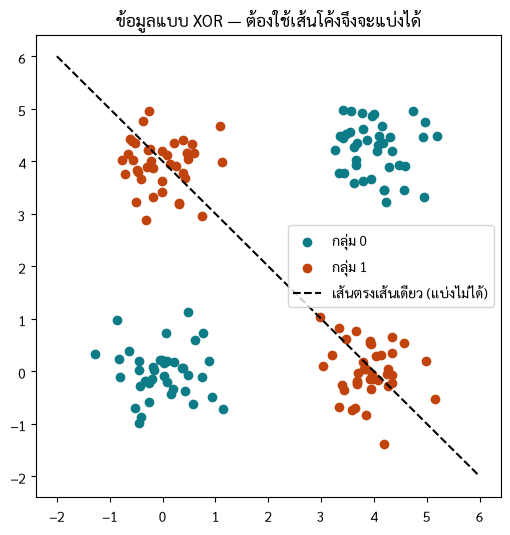

In [6]:
np.random.seed(0)
n = 40
# กลุ่ม 0: มุมล่างซ้าย + บนขวา
g0 = np.vstack([np.random.randn(n,2)*0.5 + [0,0],
                np.random.randn(n,2)*0.5 + [4,4]])
# กลุ่ม 1: มุมบนซ้าย + ล่างขวา
g1 = np.vstack([np.random.randn(n,2)*0.5 + [0,4],
                np.random.randn(n,2)*0.5 + [4,0]])

plt.figure(figsize=(6,6))
plt.scatter(g0[:,0], g0[:,1], c='#0E7C86', label='กลุ่ม 0')
plt.scatter(g1[:,0], g1[:,1], c='#C1440E', label='กลุ่ม 1')
plt.plot([-2,6],[6,-2],'k--',label='เส้นตรงเส้นเดียว (แบ่งไม่ได้)')
plt.legend(); plt.title('ข้อมูลแบบ XOR — ต้องใช้เส้นโค้งจึงจะแบ่งได้')
plt.show()

---
## 3. Activation function หน้าตาเป็นอย่างไร

พล็อต ReLU และ Sigmoid เพื่อเห็นความต่าง


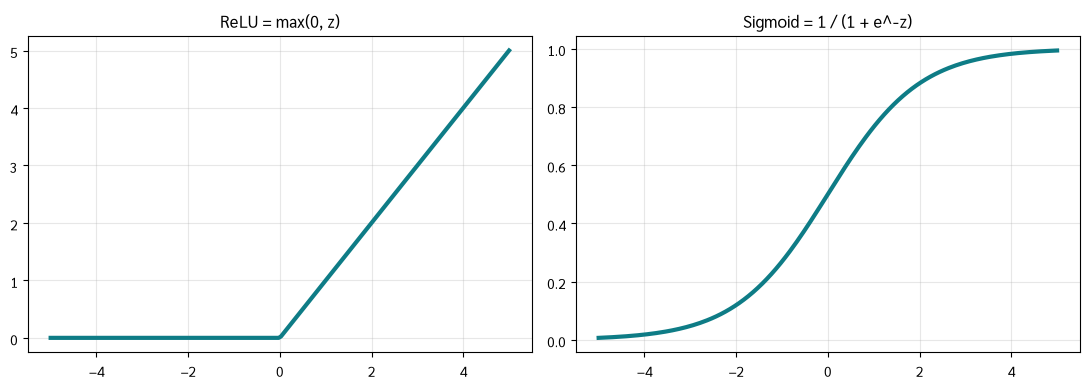

ReLU   : ค่าติดลบกลายเป็น 0, ค่าบวกผ่านไปตรง ๆ  -> ใช้ในชั้นซ่อน
Sigmoid: บีบทุกค่าให้อยู่ระหว่าง 0 ถึง 1        -> ใช้ตอนทายสองทาง


In [7]:
z = np.linspace(-5, 5, 200)

relu_y    = np.maximum(0, z)
sigmoid_y = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(z, relu_y, color='#0E7C86', linewidth=3)
ax[0].set_title('ReLU = max(0, z)'); ax[0].grid(alpha=0.3)
ax[1].plot(z, sigmoid_y, color='#0E7C86', linewidth=3)
ax[1].set_title('Sigmoid = 1 / (1 + e^-z)'); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("ReLU   : ค่าติดลบกลายเป็น 0, ค่าบวกผ่านไปตรง ๆ  -> ใช้ในชั้นซ่อน")
print("Sigmoid: บีบทุกค่าให้อยู่ระหว่าง 0 ถึง 1        -> ใช้ตอนทายสองทาง")

---
## 4. Softmax แปลงคะแนนดิบเป็นความน่าจะเป็น

จากสไลด์: คะแนนดิบ `[2.0, 1.0, 0.1]` -> `[0.66, 0.24, 0.10]`


### ขั้นที่ 4.1 — นิยาม softmax และคำนวณ

In [8]:
def softmax(scores):
    scores = np.array(scores, dtype=float)
    exp = np.exp(scores - scores.max())   # ลบ max กันเลขล้น
    return exp / exp.sum()

raw = [2.0, 1.0, 0.1]
probs = softmax(raw)

print("คะแนนดิบ     :", raw)
print("หลัง softmax  :", np.round(probs, 2))
print("ผลรวม         :", round(probs.sum(), 4), "(เท่ากับ 1 เสมอ)")

คะแนนดิบ     : [2.0, 1.0, 0.1]
หลัง softmax  : [0.66 0.24 0.1 ]
ผลรวม         : 1.0 (เท่ากับ 1 เสมอ)


### ขั้นที่ 4.2 — แสดงเป็นกราฟแท่ง

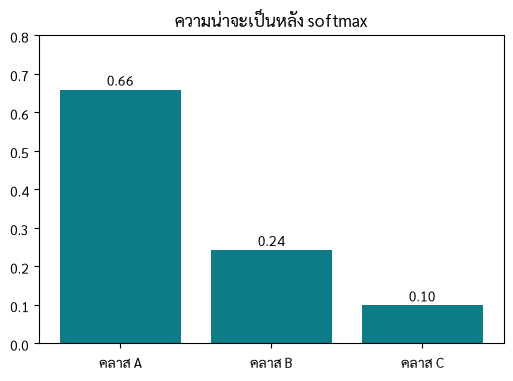

In [9]:
plt.figure(figsize=(6,4))
plt.bar(['คลาส A','คลาส B','คลาส C'], probs, color='#0E7C86')
for i, p in enumerate(probs):
    plt.text(i, p+0.01, f"{p:.2f}", ha='center')
plt.title('ความน่าจะเป็นหลัง softmax'); plt.ylim(0, 0.8)
plt.show()

---
## 5. Crossentropy ลงโทษความมั่นใจที่ผิด

จากสไลด์: ถ้าคำตอบที่ถูกคือคลาส A แต่โมเดลให้ความน่าจะเป็นกับ A ต่ำ ค่า loss จะพุ่งสูง

$$\text{loss} = -\ln(\text{ความน่าจะเป็นของคลาสที่ถูกต้อง})$$


### ขั้นที่ 5.1 — คำนวณตามสามค่าในสไลด์

In [10]:
def crossentropy(prob_correct):
    return -np.log(prob_correct)

for p in [0.90, 0.50, 0.10]:
    print(f"ให้ความน่าจะเป็นคลาสที่ถูก = {p:.2f}  ->  loss = {crossentropy(p):.2f}")

ให้ความน่าจะเป็นคลาสที่ถูก = 0.90  ->  loss = 0.11
ให้ความน่าจะเป็นคลาสที่ถูก = 0.50  ->  loss = 0.69
ให้ความน่าจะเป็นคลาสที่ถูก = 0.10  ->  loss = 2.30


### ขั้นที่ 5.2 — วาดเส้น loss เทียบกับความมั่นใจ

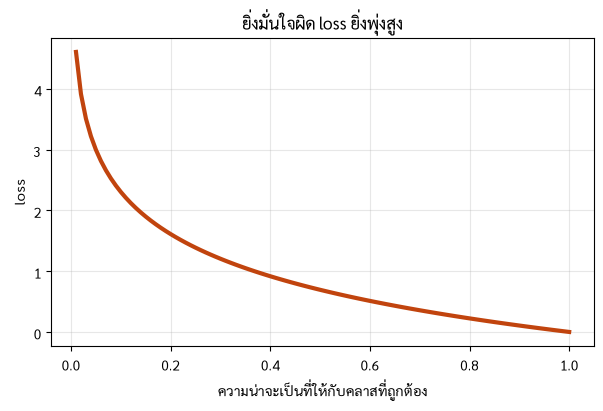

In [11]:
p = np.linspace(0.01, 1.0, 100)
plt.figure(figsize=(7,4))
plt.plot(p, crossentropy(p), color='#C1440E', linewidth=3)
plt.xlabel('ความน่าจะเป็นที่ให้กับคลาสที่ถูกต้อง')
plt.ylabel('loss')
plt.title('ยิ่งมั่นใจผิด loss ยิ่งพุ่งสูง')
plt.grid(alpha=0.3)
plt.show()

---
## 6. Gradient descent เดินลงเขา

จากสไลด์: เริ่มจากจุดสุ่ม แล้วก้าวไปทางที่ลาดลงทีละก้าว ขนาดก้าว = learning rate

ใช้ฟังก์ชันชามง่าย ๆ  `loss = w²`  ซึ่งมีจุดต่ำสุดที่ w = 0


### ขั้นที่ 6.1 — เดินลงเขาทีละก้าว

In [12]:
def loss_fn(w):
    return w**2

def gradient(w):
    return 2*w        # อนุพันธ์ของ w^2

w = 8.0               # เริ่มจากจุดสุ่ม
learning_rate = 0.1
history = [w]

for step in range(15):
    w = w - learning_rate * gradient(w)   # ก้าวลงตามความชัน
    history.append(w)

print("เส้นทางของ w:", [round(v,2) for v in history])
print(f"จบที่ w = {w:.4f}  (จุดต่ำสุดจริงคือ 0)")

เส้นทางของ w: [8.0, 6.4, 5.12, 4.1, 3.28, 2.62, 2.1, 1.68, 1.34, 1.07, 0.86, 0.69, 0.55, 0.44, 0.35, 0.28]
จบที่ w = 0.2815  (จุดต่ำสุดจริงคือ 0)


### ขั้นที่ 6.2 — วาดลูกบอลกลิ้งลงชาม

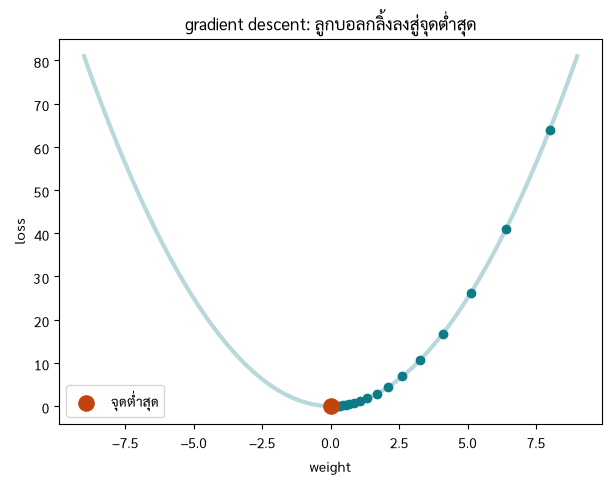

In [13]:
w_range = np.linspace(-9, 9, 100)
plt.figure(figsize=(7,5))
plt.plot(w_range, loss_fn(w_range), color='#B8D8DB', linewidth=3)
hist = np.array(history)
plt.scatter(hist, loss_fn(hist), color='#0E7C86', zorder=5)
plt.scatter([0],[0], color='#C1440E', s=120, zorder=6, label='จุดต่ำสุด')
plt.xlabel('weight'); plt.ylabel('loss')
plt.title('gradient descent: ลูกบอลกลิ้งลงสู่จุดต่ำสุด')
plt.legend(); plt.show()

**ลองเปลี่ยน `learning_rate`** ในขั้นที่ 6.1 เป็น 0.9 (ใหญ่ไป) แล้วรันสองเซลล์ใหม่
ดูว่าค่าแกว่ง หรือเป็น 0.01 (เล็กไป) ดูว่าเดินช้าไม่ถึงจุดต่ำสุดใน 15 ก้าว

---
## 7. Epoch / Batch / Step

จากสไลด์: ข้อมูล 60,000 ภาพ batch size 32 -> หนึ่ง epoch มีกี่ step


### ขั้นที่ 7.1 — คำนวณจำนวน step

In [14]:
n_samples = 60000
batch_size = 32
epochs = 10

steps_per_epoch = n_samples // batch_size
total_steps = steps_per_epoch * epochs

print(f"ข้อมูลทั้งหมด      : {n_samples:,} ภาพ")
print(f"batch size         : {batch_size}")
print(f"1 epoch            : {steps_per_epoch:,} steps")
print(f"ฝึก {epochs} epochs  : ปรับ parameter {total_steps:,} ครั้ง")

ข้อมูลทั้งหมด      : 60,000 ภาพ
batch size         : 32
1 epoch            : 1,875 steps
ฝึก 10 epochs  : ปรับ parameter 18,750 ครั้ง


### ขั้นที่ 7.2 — batch ใหญ่ขึ้น step น้อยลง

In [15]:
print(f"{'batch size':>12} | {'steps ต่อ epoch':>16}")
print("-"*32)
for bs in [16, 32, 64, 128, 256]:
    print(f"{bs:>12} | {n_samples//bs:>16,}")

  batch size |  steps ต่อ epoch
--------------------------------
          16 |            3,750
          32 |            1,875
          64 |              937
         128 |              468
         256 |              234


---
## สรุป

โน้ตบุ๊กนี้แสดงให้เห็นว่าแนวคิดในสไลด์ช่วงเช้าทุกอันเป็นการคำนวณที่จับต้องได้

ช่วงบ่ายจะนำแนวคิดเหล่านี้ไปสร้างโมเดลจริงด้วย Keras:
- perceptron กลายเป็น `layers.Dense`
- activation กลายเป็น `activation='relu'`
- gradient descent กลายเป็น `optimizer='adam'`
- crossentropy กลายเป็น `loss='sparse_categorical_crossentropy'`
